In [24]:
import cv2
filename = "../data/level1/sample.jpg"
img = cv2.imread(filename, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("Failed to load image: {:s}".format(filename))

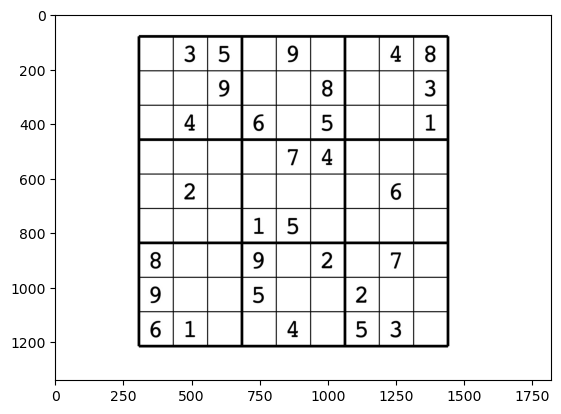

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

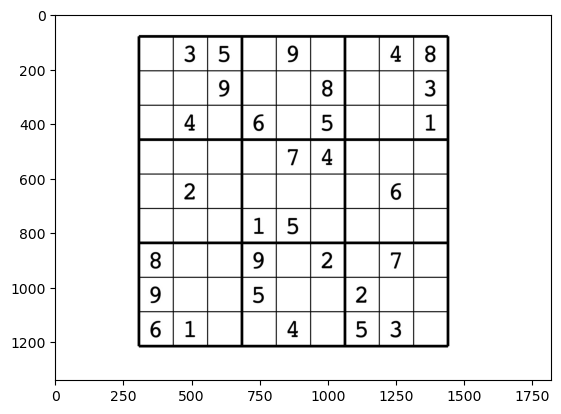

In [9]:
# 画像をグレースケールにする
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img)
plt.show()

In [10]:
# Sobelフィルタ
import numpy as np
dx = cv2.Sobel(gray, cv2.CV_8U, 1, 0)
dy = cv2.Sobel(gray, cv2.CV_8U, 0, 1)
sobel = np.sqrt(dx * dx + dy * dy)
sobel = (sobel - sobel.min()) / (sobel.max() - sobel.min())
sobel = (sobel * 255.0).astype("uint8")
_, sobel = cv2.threshold(sobel, 10, 255, cv2.THRESH_BINARY)

# Canny法
canny = cv2.Canny(gray, 100, 200)



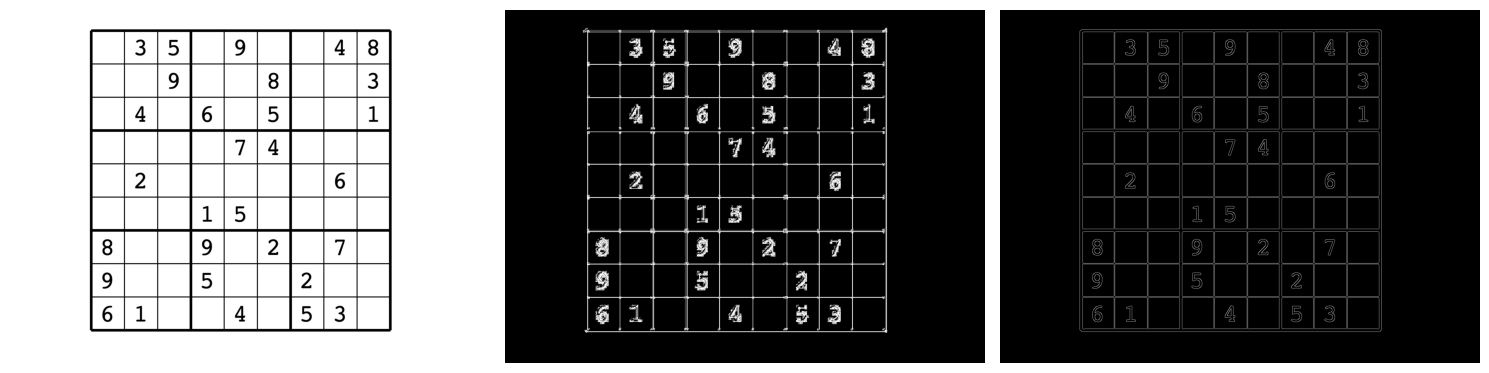

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.imshow(img)
ax.axis("off")

ax = fig.add_subplot(132)
ax.imshow(sobel, cmap="gray")
ax.axis("off")

ax = fig.add_subplot(133)
ax.imshow(canny, cmap="gray")
ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
binary = sobel.copy()
res_dilate = cv2.dilate(binary, np.ones((5, 5), dtype=binary.dtype))
res_erode = cv2.erode(binary, np.ones((5, 5), dtype=binary.dtype))

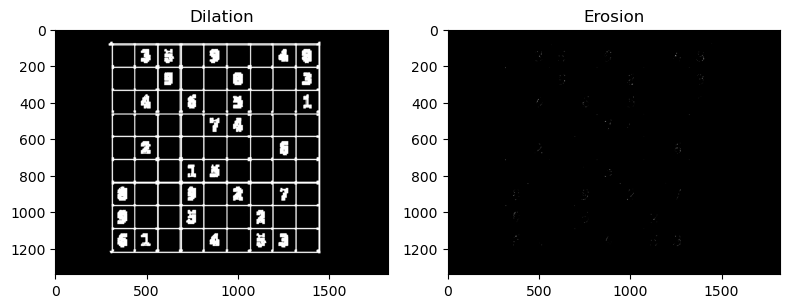

In [16]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121)
ax.imshow(res_dilate, cmap="gray")
ax.set_title("Dilation")
ax = fig.add_subplot(122)
ax.imshow(res_erode, cmap="gray")
ax.set_title("Erosion")
plt.tight_layout()
plt.show()

In [17]:
res = sobel.copy()
res = cv2.dilate(res, np.ones((5, 5), dtype=binary.dtype))
res = cv2.erode(res, np.ones((5, 5), dtype=binary.dtype))

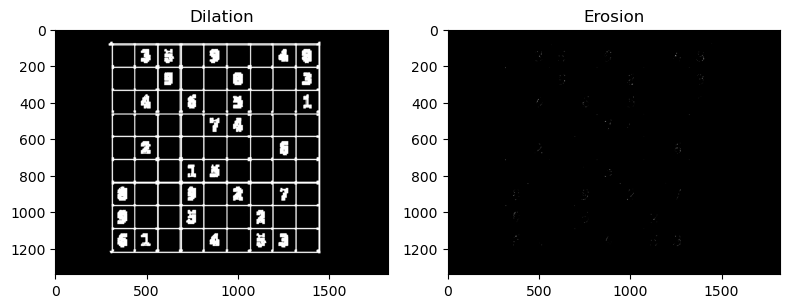

In [18]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121)
ax.imshow(res_dilate, cmap="gray")
ax.set_title("Dilation")
ax = fig.add_subplot(122)
ax.imshow(res_erode, cmap="gray")
ax.set_title("Erosion")
plt.tight_layout()
plt.show()

In [19]:
import cv2
import numpy as np

# 画像を読み込む
# img = cv2.imread('your_image.png')

# グレースケールに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 二値化
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
largest_contour = max(contours, key=cv2.contourArea)

# マス目の輪郭の四角を描く
x, y, w, h = cv2.boundingRect(largest_contour)
cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

# 各マス目の輪郭を描く
stepx = w // 9
stepy = h // 9
for i in range(9):
    for j in range(9):
        cv2.rectangle(img, (x + i*stepx, y + j*stepy), (x + (i+1)*stepx, y + (j+1)*stepy), (0, 255, 0), 2)

# 画像を表示する
cv2.imshow('Grid', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [26]:
import cv2
import numpy as np

# 画像を読み込む
# img = cv2.imread('your_image.png')

# グレースケールに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 二値化
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
largest_contour = max(contours, key=cv2.contourArea)

# マス目の輪郭の四角を描く
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9
stepy = h // 9
for i in range(9):
    for j in range(9):
        cell = img[y + j*stepy:y + (j+1)*stepy, x + i*stepx:x + (i+1)*stepx]
        cell_images.append(cell)

# 例として、抽出したマス目の画像を保存
for idx, cell in enumerate(cell_images):
    cv2.imwrite(f"cell_{idx}.png", cell)
